의사결정나무~
- 회귀보다는..로지스틱? 의 발전형..., 회귀에서는 예측력이 낮음


나무 구조
너무 많이 쪼개면 과적합 > 하이퍼 파라미터로 조절 필요

순수한 그룹으로 만들어간다....


둘다낮을수록 좋은 값

지니지수~

엔트로피 지수~

============
hs_get_scores

동시작업 못해서 n jobs 파라미터 없음



============
모델 적합 
트리는 스케일링 안해도 괜찮음~~
파이프라인 안써도 괜찮~~






같은데이터더라도 모델에따라 일반화 성공 여부가 다 달라
shap 분석
예측값을 가지고 각 변수들이 이 예측값을 도출하는데 얼마나 ㄷ출해는가?
방향성까지 나옴

shap 은 각 데이터 한줄씩에 대한 영향력 설명이 가능해짐
결과설명용

train 데이터로 해야해!!! > 모델이 학습한 구조를 설명하기 위한거니까

안정석 (종속변수에 영향 ㅇ)
비선형 불안정 (종속변수에 영향 x)


weekend
영향력이 가장 큰데 뜨문뜨문 준다



shap 써머리 플럿~

그래프는 한줄로 할수있는데,,, 글씨조절같은 세세한 옵션이 안되니까
파이플롯으로 튜닝~


그래프
왼쪽으로 갈수록 종속변수에 대한 영향이 낮은거야~!

2진값> 이진값이니까 낮으면 마이너스 ~ 높으면 플러스~


종속변수에 대한 영향력 shap value


마케팅비용과
상호작용여부가 색상으로 나옴
두드러지게 군집이 있따 > 뚜렷한 효과를 주는데
섞여있다? > 큰 상호작용 ㅓㅄ는 것 
불연속적 패턴 > 임계 구간이 있음


양향력이 높게 나온 변수끼리의 조합만 상호작용 확인

==========================
위에는 매풀의 평균...
이제는 레코드 한줄한줄에 대한 개별 설명력!

최대,최소,평균,중앙값에 대해서


idxmax > 최대값의 index 

인덱스가 날짜값으로 설정되어있음

pos


전부 빨강 > 매출액 상승으로 작용하는 변수들임!

base value 랑 f(x) 값으 비교했을 떄..다 파랑색 


각 넓이는 각 변수가 가지고 있는 지분을 의미함



평일과 주말에는 마케티조금해서는 영향이 적다~





# [LAB 07] 지도학습 > 예측 > 비선형 > 02.트리 | DecisionTree

## #01.의사결정트리 개요



### [1] 기본 개념

### 스무고개 방식의 규칙 기반 모델
- 의사결정 규칙을 나무(Tree) 구조로 표현하여 지식을 일반화한 모델
- 분류와 회귀 모두 가능하나, 단일 트리 기준에서는 분류에 더 적합
- 회귀 문제는 성능 한계가 있어 XGBoost, LightGBM 등으로 확장하여 사용
- if ~ else 형태의 규칙 집합으로 해석 가능

---

### [2] 핵심 아이디어

- 가장 좋은 질문을 반복해서 데이터를 점점 단순한 규칙으로 나누는 모델
- 질문을 하나씩 던지며 데이터를 분할 (if ~ else 규칙의 반복)
- 매 단계에서 가장 잘 구분되는 질문을 선택
  - 순수도(지니, 엔트로피)가 가장 많이 개선되는 분할 선택
- 데이터를 점점 더 순수한 그룹으로 만듦
  - 한 노드에 한 클래스만 남는 방향
- 멈춤 조건이 없으면 과적합 발생
  - 깊이 제한
  - 최소 샘플 수
  - 가지치기 필요

---

### [3] 의사결정트리 특징

#### 1) 장점
- 규칙 구조가 직관적 → 해석 용이
- 범주형, 연속형 변수 모두 사용 가능
- 변수 중요도 파악 가능
- 학습 및 예측 속도 빠름

#### 2) 단점
- 회귀 문제에서 예측 성능 낮음
- 트리가 깊어질수록 과적합 발생
- 데이터 변화에 민감 → 안정성 낮음
- 복잡한 트리는 해석 어려움

---

### 02. 의사결정트리 진행 절차

#### [1] 프로세스

#### Step 1
- 데이터를 가장 잘 구분할 수 있는 질문을 기준으로 분할
- 변수 중 하나 x_i 선택
- 해당 변수의 값 중 하나 s_i를 기준으로 분할

x_i → (x_i < s_i) 또는 (x_i ≥ s_i)

---

#### Step 2
- 나뉜 각 범주에서 다시 가장 잘 구분할 수 있는 질문으로 분할
- 원하는 순수도에 도달할 때까지 반복 수행

---

#### 주의
- 데이터를 지나치게 많이 나누면 오버피팅 발생
- 결정 트리에 제약 없이 학습하면 과적합됨
  - max_depth
  - min_samples_split
  - min_samples_leaf 등의 하이퍼파라미터 필요

---

### [2] 의사결정트리 분리

| 구분 | 내용 |
|---|---|
| 반복적 분할 | 훈련 데이터를 이용하여 독립변수의 차원 공간을 반복적으로 분할 |
| 가지치기 | 평가 데이터를 이용하여 가지치기 수행 |
| 분할 기준 | 부모 노드보다 자식 노드의 순수도가 증가하도록 분할 |
|  | 특정 범주의 개체들이 많이 포함된 정도 |

- 순수한 데이터 비율이 높을수록 완벽한 트리가 됨

---

### [3] 분리 기준

| 기준 | 설명 |
|---|---|
| 지니 지수 | 지니 지수를 감소시키는 예측변수와 최적 분리에 의해 자식 노드 선택 |
| 엔트로피 지수 | 엔트로피 지수가 가장 작은 예측변수와 최적 분리에 의해 자식 노드 형성 |

---

### [4] 지니 지수 (Gini Index)

- 데이터 셋의 불순도(impurity) 또는 분산을 측정하는 지표
- 클래스 분포의 균일성을 나타냄
- 값의 범위: 0 ~ 1
- 값이 낮을수록 데이터 순도가 높음
  - 0에 가까움: 하나의 클래스만 존재
  - 1에 가까움: 클래스가 고르게 섞임

#### 분할 방식
- 각 가능한 분할에 대해 지니 지수 계산
- 지니 지수가 가장 많이 감소하는 분할 선택
- 전체 분할 후 지니 지수의 가중 평균을 최소화

#### 예시 데이터 분포

| 경우 | 클래스 A | 클래스 B | 분포 특징 |
|---|---|---|---|
| 경우 ① | 5 | 5 | 완전 혼합 |
| 경우 ② | 8 | 2 | 어느 정도 치우침 |
| 경우 ③ | 10 | 0 | 완전 순수 |

#### 지니 지수 직관
- 무작위로 하나를 뽑았을 때 다른 클래스가 나올 확률
- “얼마나 섞여 있는가?”를 나타냄

| 경우 | 지니 지수 | 해석 |
|---|---|---|
| 5:5 | 0.5 | 매우 섞임 |
| 8:2 | 0.32 | 덜 섞임 |
| 10:0 | 0.0 | 전혀 섞이지 않음 |

---

### [5] 엔트로피 지수 (Entropy)

- 정보 이론에서 유래한 개념
- 데이터 셋 내의 불확실성(혼잡도)을 수치화한 값
- 클래스 분포의 균일성을 측정

#### 특징
- 엔트로피 값이 높을수록 불확실성 큼
- 엔트로피 값이 낮을수록 특정 클래스가 지배적

#### 분할 기준
- 각 분할에 대해 엔트로피 계산
- 정보 이득(Information Gain)이 가장 큰 분할 선택
- 이 과정을 반복하여 순도가 높은 자식 노드를 생성


## #03.준비작업
### [1] 패키지 참조

In [1]:
from hossam import *

from pandas import DataFrame
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve

# 성능평가지표 모듈
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

# 의사결정나무
from sklearn.tree import DecisionTreeRegressor

# 신규 - 설치 필요 (pip install --upgrade shap)
import shap

### [2] 성능 평가 함수

In [2]:
def hs_get_scores(estimator, x_test, y_true):
    if hasattr(estimator, "named_steps"):
        classname = estimator.named_steps["model"].__class__.__name__
    else:
        classname = estimator.__class__.__name__

    y_pred = estimator.predict(x_test)

    return DataFrame(
        {
            "결정계수(R2)": r2_score(y_true, y_pred),
            "평균절대오차(MAE)": mean_absolute_error(y_true, y_pred),
            "평균제곱오차(MSE)": mean_squared_error(y_true, y_pred),
            "평균오차(RMSE)": np.sqrt(mean_squared_error(y_true, y_pred)),
            "평균 절대 백분오차 비율(MAPE)": mean_absolute_percentage_error(
                y_true, y_pred
            ),
            "평균 비율 오차(MPE)": np.mean((y_true - y_pred) / y_true * 100),
        },
        index=[classname],
    )

#### 과적합 판정 함수

In [3]:
def hs_learning_cv(
    estimator,
    x,
    y,
    scoring="neg_root_mean_squared_error",
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
):
    train_sizes, train_scores, cv_scores = learning_curve(
        estimator=estimator,
        X=x,
        y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        shuffle=True,
        random_state=52,
    )

    if hasattr(estimator, "named_steps"):
        classname = estimator.named_steps["model"].__class__.__name__
    else:
        classname = estimator.__class__.__name__

    print(f"=== Learning Curve: {classname} ===")

    # neg RMSE -> RMSE
    train_rmse = -train_scores
    cv_rmse = -cv_scores

    # 평균 / 표준편차
    train_mean = train_rmse.mean(axis=1)
    cv_mean = cv_rmse.mean(axis=1)
    cv_std = cv_rmse.std(axis=1)

    # 마지막 지점 기준 값만 가져옴
    final_train = train_mean[-1]
    final_cv = cv_mean[-1]
    final_std = cv_std[-1]

    gap_ratio = final_train / final_cv
    var_ratio = final_std / final_cv

    # -------------------------
    # 과적합 기준 (some_threshold)
    # -------------------------

    # 기준 RMSE (평균 예측)
    y_mean = y.mean()
    rmse_naive = np.sqrt(np.mean((y - y_mean) ** 2))

    # 분산 기반
    std_y = y.std()

    # 최소 설명력(R2) 기반
    min_r2 = 0.10
    rmse_r2 = np.sqrt((1 - min_r2) * np.var(y))

    # 최종 threshold (가장 관대한 기준)
    some_threshold = min(rmse_naive, std_y, rmse_r2)

    # -------------------------
    # 판정 로직
    # -------------------------
    if gap_ratio >= 0.95 and final_cv > some_threshold:
        status = "🟥 과소적합 (bias 큼)"
    elif gap_ratio <= 0.8:
        status = "🟥 과적합 (variance 큼)"
    elif gap_ratio <= 0.95 and var_ratio <= 0.10:
        status = "✅ 일반화 양호"
    elif var_ratio > 0.15:
        status = "🟨 데이터 부족 / 분산 큼"
    else:
        status = "🟨 판단 유보"

    # -------------------------
    # 정량 결과 표
    # -------------------------
    result_df = DataFrame(
        {
            "지표": [
                "Train RMSE",
                "CV RMSE 평균",
                "CV RMSE 표준편차",
                "Train/CV 비율",
                "CV 변동성 비율",
                "판정 결과",
            ],
            "값": [
                final_train,
                final_cv,
                final_std,
                gap_ratio,
                var_ratio,
                status,
            ],
        }
    )

    display(result_df)

    # -------------------------
    # 학습곡선 시각화
    # -------------------------
    figsize = (1280 / my_dpi, 720 / my_dpi)
    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

    sb.lineplot(
        x=train_sizes,
        y=train_mean,
        marker="o",
        markeredgecolor="#ffffff",
        label="Train RMSE",
    )

    sb.lineplot(
        x=train_sizes,
        y=cv_mean,
        marker="o",
        markeredgecolor="#ffffff",
        label="CV RMSE",
    )

    ax.set_xlabel("학습 데이터 크기", fontsize=8, labelpad=5)
    ax.set_ylabel("RMSE (Learning Curve)", fontsize=8, labelpad=5)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.close()


### [3] 데이터 가져오기 + 인덱스,타입변환

In [4]:
origin = load_data("restaurant_sales_preprocessed")
origin.set_index("date", inplace=True)
origin["holiday"] = origin["holiday"].astype("category")
origin["weekend"] = origin["weekend"].astype("category")
origin.info()


어느 식당의 1년간 일별 매출을 기록한 데이터의 전처리 완료 버전(명목형이 이진변수만 있으므로 더미변수는 처리하지 않음)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 353 entries, 2024-01-01 to 2024-12-30
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   sales           353 non-null    float64 
 1   visitors        353 non-null    int64   
 2   avg_price       353 non-null    int64   
 3   marketing_cost  353 non-null    float64 
 4   delivery_ratio  353 non-null    float64 
 5   rain_mm         353 non-null    float64 
 6   temperature     353 non-null    float64 
 7   holiday         353 non-null    category
 8   weekend         353 non-null    category
dtypes: category(2), float64(5), int64(2)
memory usage: 23.0 KB


### [4] 훈련 검증 데이터 분리 

In [5]:
df = origin

yname = "sales"
x = df.drop(columns=[yname])
y = df[yname]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=52
)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((264, 8), (89, 8), (264,), (89,))

## #04 DecisionTreeRegressor 모델 적합

### [1] 주요 하이퍼 파라미터

DecisionTreeRegressor에는 n_jobs 파라미터가 존재하지 않음

| 파라미터명 | 핵심도 | 설명 | 기본값 | GridSearchCV 권장값 |
|---|---|---|---|---|
| max_depth | ★★★ | 트리 최대 깊이 (과적합 직접 제어) | None | [3, 5, 7, 10, 15] |
| min_samples_split | ★★★ | 노드를 분할하기 위한 최소 샘플 수 | 2 | [2, 5, 10, 20] |
| min_samples_leaf | ★★★ | 리프 노드가 가져야 할 최소 샘플 수 | 1 | [1, 5, 10, 20] |
| max_features | ★★ | 분할 시 고려할 최대 변수 수 | None | [None, 'sqrt', 'log2'] |
| criterion | ★★ | 분할 기준 손실 함수 (회귀/분류별 다름) | 'squared_error' | ['squared_error', 'absolute_error'] |
| max_leaf_nodes | ★ | 리프 노드 최대 개수 | None | [None, 10, 20, 30, 50] |
| min_impurity_decrease | ★ | 분할 수행을 위한 최소 순도 감소량 | 0.0 | [0.0, 0.01, 0.1] |
| random_state | ✅ | 재현성 확보 시드 | None | 52 |

### [2] 모델 적합
- 트리 계열 모델은 스케일링을 거치지 않음

In [6]:
%%time

dt = DecisionTreeRegressor(random_state=52)

# 하이퍼파라미터 그리드
param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 5, 10, 20],
    "max_features": [None, "sqrt", "log2"],
    "criterion": ["squared_error", "absolute_error"],
    "max_leaf_nodes": [None, 10, 20, 30, 50],
    "min_impurity_decrease": [0.0, 0.01, 0.1],
}

# GridSearchCV
gs = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# 학습
gs.fit(x_train, y_train)

# 최적 모델
best_model = gs.best_estimator_

CPU times: total: 6.39 s
Wall time: 31.2 s


## #05.성능평가
### [1] 성능평가표

In [7]:
hs_get_scores(best_model, x_test, y_test)

,결정계수(R2),평균절대오차(MAE),평균제곱오차(MSE),평균오차(RMSE),평균 절대 백분오차 비율(MAPE),평균 비율 오차(MPE)
DecisionTreeRegressor,0.620,0.196,0.054,0.233,0.012,0.353


### [2] 과적합 판정

=== Learning Curve: DecisionTreeRegressor ===


,지표,값
0,Train RMSE,0.224
1,CV RMSE 평균,0.245
2,CV RMSE 표준편차,0.018
3,Train/CV 비율,0.912
4,CV 변동성 비율,0.072
5,판정 결과,✅ 일반화 양호


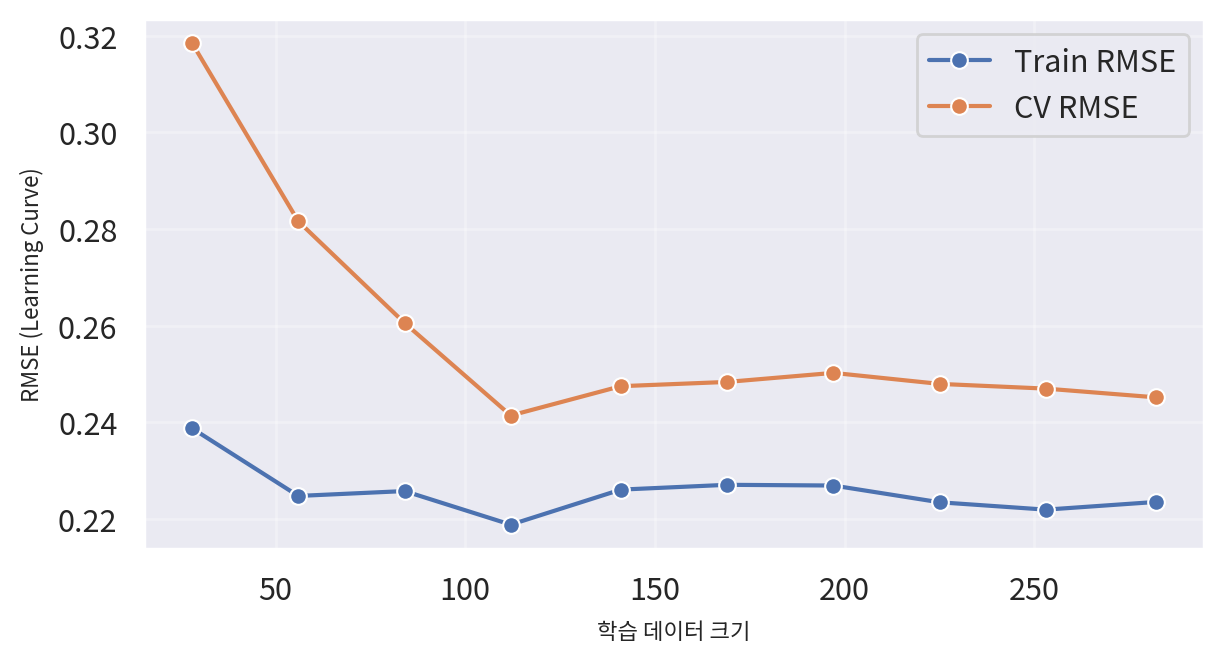

In [8]:
hs_learning_cv(best_model, x, y)

## #06.SHAP 분석

### [1] 개요

- 예측값을 변수 기여도로 설명하는 도구
  - 모델 예측값을 변수 기여도로 분해하는 방법
  - 각 변수는 예측값에 얼마나 (+ / -) 기여했는지를 의미
  - 기준점은 전체 평균 예측값

- 트리 모델 해석에 특히 적합
  - 선형, KNN, SVM에도 적용 가능하지만 계산량이 커서 권장하지 않음
  - 딥러닝(신경망)에도 적용 가능

- SHAP 기본 수식

\[
\hat{y} = \mathbb{E}[\hat{y}] + \sum_{j=1}^{p} SHAP_j
\]

---

### [2] 핵심 아이디어

- 게임이론의 Shapley Value 기반
  - 각 변수를 플레이어로 간주
  - 모든 변수 조합에서의 평균 기여도를 계산

- 하나의 예측값을 변수별 기여도의 합으로 설명
  - 질문 형태로 해석 가능  
    - “이 예측이 평균보다 높거나 낮아진 이유는?”

---

### [3] Feature Importance와 비교

| 구분 | Feature Importance | SHAP |
|---|---|---|
| 방향성 | 없음 | 있음 |
| 개별 예측 설명 | 불가 | 가능 |
| 해석력 | 낮음 | 높음 |

---

### [4] 종류

| 구분 | SHAP 종류 | 대상 모델 | 특징 |
|---|---|---|---|
| ① | TreeExplainer | 결정트리, 랜덤포레스트, XGBoost, LightGBM | 정확, 빠름, 실무 표준 |
| ② | LinearExplainer | 선형회귀, 로지스틱 회귀 | 계산 단순, 해석 명확 |
| ③ | KernelExplainer | 모든 모델 (모든 경우의 수 계산) | 범용, 매우 느림 |
| ④ | DeepExplainer | 딥러닝 모델 | 신경망 전용 |
| ⑤ | SamplingExplainer | 모든 모델 | 근사 계산, Kernel보다 빠름 |

---

### [5] SHAP 분석 (회귀모형 계열)

- SHAP은 모델 내부 판단 구조를 설명하는 도구
  - 모델이 “학습한 구조”를 설명하는 것이 목적
  - 학습에 사용된 분포는 `x_train`

- 따라서
  - 전역 해석 (변수 중요도, 규칙 성향) → `x_train` 기준 사용

- 만약
  - “새 데이터에서 이 예측이 왜 나왔나?”를 설명하려면 → `x_test` 사용


In [9]:
# SHAP Explainer 생성
explainer = shap.TreeExplainer(best_model)

# SHAP 값 계산
# (회귀 기준: shape = [n_samples, n_features])
shap_values = explainer.shap_values(x_train)

# SHAP 결과를 DataFrame으로 변환
shap_df = DataFrame(
    shap_values,
    columns=x_train.columns,
    index=x_train.index
)

shap_df

,visitors,avg_price,marketing_cost,delivery_ratio,rain_mm,temperature,holiday,weekend
date,,,,,,,,
2024-06-11,0.000,-0.008,0.002,0.000,0.000,0.000,-0.024,-0.136
2024-06-20,0.000,0.031,-0.159,0.000,0.000,0.000,-0.028,-0.196
2024-08-25,0.000,0.036,0.238,0.000,0.000,0.000,0.183,0.171
2024-11-22,0.000,-0.000,-0.002,0.000,0.000,0.000,-0.028,-0.136
2024-12-30,0.000,-0.008,0.002,0.000,0.000,0.000,-0.024,-0.136
...,...,...,...,...,...,...,...,...
2024-03-30,0.000,-0.024,-0.082,0.000,0.000,0.000,0.030,0.429
2024-06-04,0.000,0.031,0.001,0.000,0.000,0.000,-0.028,-0.170
2024-01-14,0.000,-0.024,-0.082,0.000,0.000,0.000,0.030,0.429


### [6] SHAP 분석 결과 요약 표

In [10]:
# [6] SHAP 분석 결과 요약 표

summary_df = DataFrame(
    {
        "feature": shap_df.columns,
        "mean_abs_shap": shap_df.abs().mean().values,
        "mean_shap": shap_df.mean().values,
        "std_shap": shap_df.std().values,
    }
)

# 영향 방향 해석
summary_df["direction"] = np.sign(summary_df["mean_shap"]).map(
    {1: "증가", -1: "감소", 0: "중립"}
)

# 안정성 지표 (변동성 / 평균 영향)
summary_df["cv"] = summary_df["std_shap"] / (summary_df["mean_abs_shap"] + 1e-9)
summary_df["stability"] = np.where(
    summary_df["cv"] < 1, "안정적", "비선형/불안정"
)

# 중요도 기준 정렬
summary_df = summary_df.sort_values(
    by="mean_abs_shap", ascending=False
).reset_index(drop=True)

summary_df


,feature,mean_abs_shap,mean_shap,std_shap,direction,cv,stability
0,weekend,0.193,0.008,0.224,증가,1.162,비선형/불안정
1,marketing_cost,0.090,-0.000,0.130,감소,1.448,비선형/불안정
2,holiday,0.057,-0.006,0.081,감소,1.419,비선형/불안정
3,avg_price,0.015,-0.001,0.029,감소,1.923,비선형/불안정
4,delivery_ratio,0.000,0.000,0.000,중립,0.000,안정적
5,visitors,0.000,0.000,0.000,중립,0.000,안정적
6,temperature,0.000,0.000,0.000,중립,0.000,안정적
7,rain_mm,0.000,0.000,0.000,중립,0.000,안정적


#### ✏️ 해석규칙

| 컬럼 | 해석 |
|---|---|
| mean_abs_shap | 클수록 중요한 변수 |
| mean_shap | +면 예측 증가, -면 예측 감소 |
| direction | 영향 방향 요약 |
| std_shap | 상황별 영향 차이 |
| stability | 단조 vs 비선형 판단 힌트 |

---

### 💡 인사이트

#### 📊 피처 중요도 분석
- **weekend(주말 여부)**  
  - mean_abs_shap = 0.193으로 가장 영향력 있는 피처  
  - 주말에 매출 변동이 가장 큼

#### 💰 상위 영향도 피처
- 상위 3개 피처  
  - weekend (0.193)  
  - marketing_cost (0.090)  
  - holiday (0.057)  
- 이들 피처의 조합이 매출 변동의 주요 요인

#### 📉 낮은 영향도 피처
- avg_price: 0.015  
  → 평균 가격은 매출액에 미미한 영향
- visitors, delivery_ratio, rain_mm, temperature  
  → 모두 0.000  
  → 모델의 매출 예측에 거의 영향을 미치지 않음

#### 🔎 주목할 점
- 날씨 요인(온도, 강수량)이 매출에 영향을 주지 않음  
  → 이 식당의 매출은 계절성이나 날씨 의존도가 낮음
- 방문객 수 영향도 0.000  
  → 모델이 방문객 수를 통한 매출 예측 경로를 학습하지 않음
- 배달 비율 영향도 0.000  
  → 배달 채널이 매출 변동에 영향을 주지 않음


### [6] Summary Plot
- x축: SHAP 값  
- 색상: 변수값 크기  
- 변수 중요도 + 방향성을 동시에 확인 가능

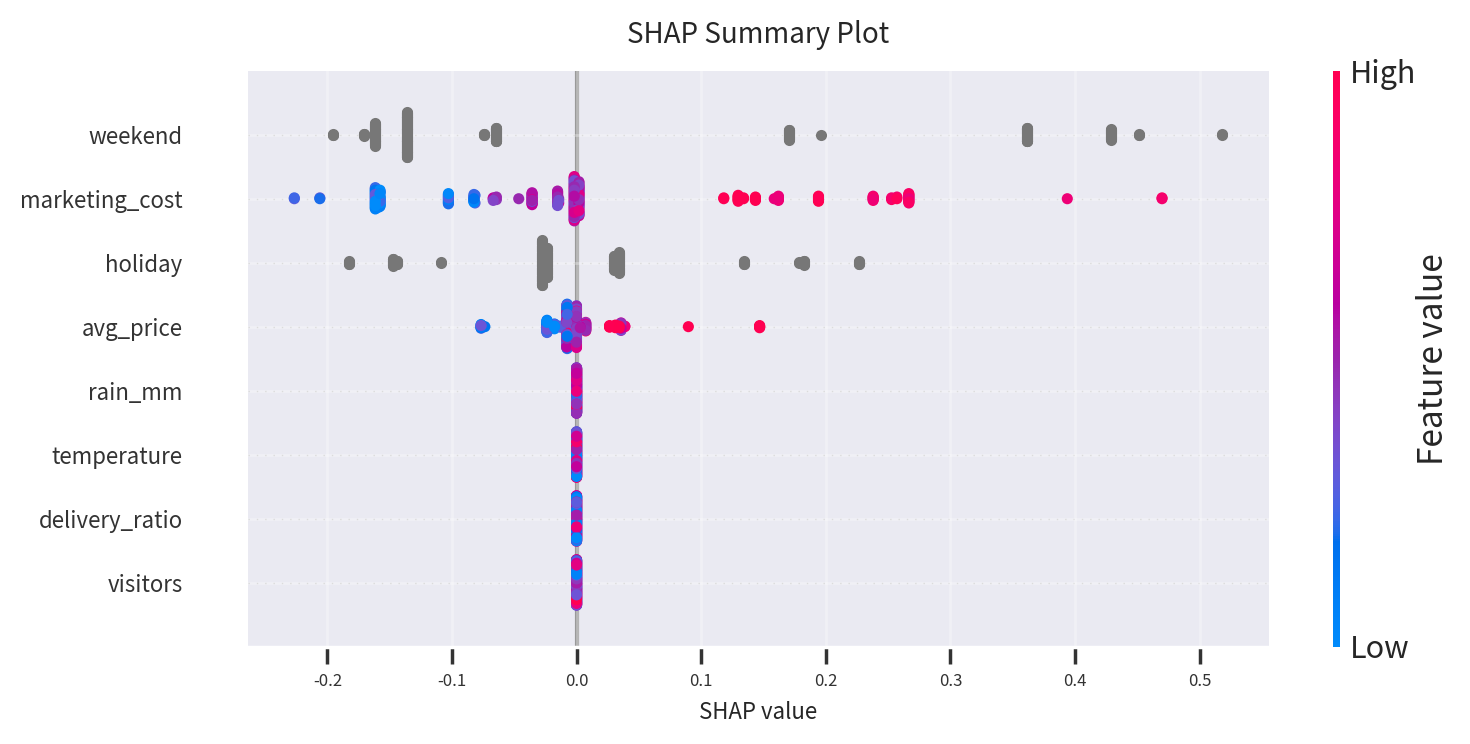

In [11]:
shap.summary_plot(shap_values, x_train, show=False)

fig = plt.gcf()
fig.set_size_inches(1600 / my_dpi, 800 / my_dpi)

plt.title("SHAP Summary Plot", fontsize=10, pad=10)
plt.xlabel("SHAP value", fontsize=8)
plt.xticks(fontsize=6)
plt.yticks(fontsize=8)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()


### 📊 SHAP Beeswarm Plot 시각화 해석 방법

- x축: SHAP value  
  - 모델 예측값에 미치는 영향의 크기와 방향
  - 음수(-): 매출 감소 방향
  - 양수(+): 매출 증가 방향
- y축: 피처(특성) 이름
- 색상: Feature value  
  - 파란색: Low  
  - 빨간색: High
- 점의 위치: 관측치(일별 데이터)의 SHAP 값
- 점의 퍼짐 정도:
  - 퍼질수록 매출 변동에 큰 영향
  - 0 근처에 몰릴수록 영향 미미


### 💡 인사이트 (Beeswarm)

### 주말(weekend)
- 가장 강력한 영향 요소
- SHAP 값 범위: 약 -0.2 ~ 0.5
- 주말과 평일의 매출 차이가 극적으로 나타남
- 주말일 때 매출이 크게 증가하는 경향

### 마케팅 비용(marketing_cost)
- 명확한 양의 상관관계
- Low 값(파란색 점): 음의 영향 (-0.1 ~ 0.0)
- High 값(빨간색 점): 양의 영향 (0.0 ~ 0.4)
- 마케팅 비용이 높을수록 매출 증가를 모델이 학습

### 휴일(holiday)
- 약한 영향력
- 대부분의 점이 0 근처 (-0.1 ~ 0.1)
- 휴일 자체는 주말보다 영향력이 훨씬 약함

### 평균 가격(avg_price)
- 거의 영향 없음
- 대부분 0 근처에 집중
- 일부 이상치(outlier)만 영향
- 가격 변동은 매출 예측에 거의 기여하지 않음

### 외부 요소
- visitors, delivery_ratio, rain_mm, temperature
- 모든 점이 0 근처
- 모델이 이 피처들을 매출 설명에 거의 사용하지 않음


### [7] Dependence Plot

- 특정 변수값과 SHAP 값의 관계 시각화
- 비선형성, 임계점 확인 가능


#### 마케팅 비용 효과와 평균 가격 간 상호작용

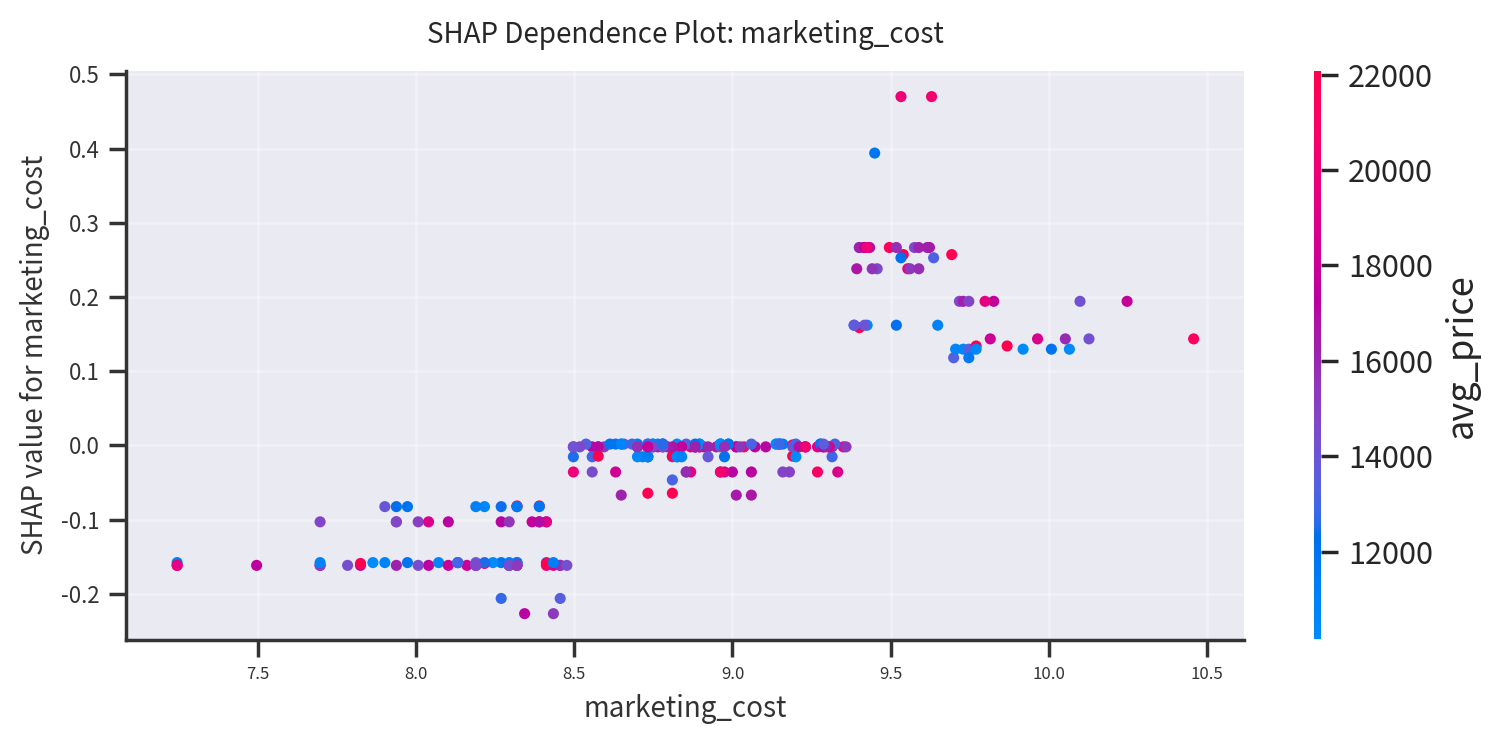

In [12]:
feature_name = "marketing_cost"

shap.dependence_plot(
    feature_name,
    shap_values,
    x_train,
    interaction_index="avg_price",
    show=False,
)

fig = plt.gcf()
fig.set_size_inches(1600 / my_dpi, 800 / my_dpi)

plt.title(f"SHAP Dependence Plot: {feature_name}", fontsize=10, pad=10)
plt.xlabel("marketing_cost", fontsize=10)
plt.ylabel("SHAP value for marketing_cost", fontsize=10)
plt.xticks(fontsize=6)
plt.yticks(fontsize=8)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()


#### 💡 인사이트

- ✅ 마케팅 비용과 SHAP 영향의 단계적 변화
  - marketing_cost가 낮은 구간(약 7.4~8.5)에서는 SHAP 값이 음수(약 -0.22~-0.08) → 매출액 감소 방향 영향
  - 중간 구간(약 8.6~9.3)에서는 SHAP 값이 0 근처 → 영향 거의 없음
  - 높은 구간(약 9.4~10.5)에서는 SHAP 값이 양수(약 0.1~0.5) → 매출액 증가 방향 영향

- 🍖 불연속적 패턴
  - 점들이 몇 개의 수평 띠 형태로 분포 → 특정 임계 구간에서 영향이 급변하는 구조

- 🎨 avg_price 색상과 영향의 혼재
  - 동일한 marketing_cost 구간에서 색상이 다양하게 섞임
  - avg_price(색상)는 이 플롯에서 marketing_cost의 영향 방향을 일관되게 설명하지 못함



#### 주말 여부와 마케팅 비용간 상호작용

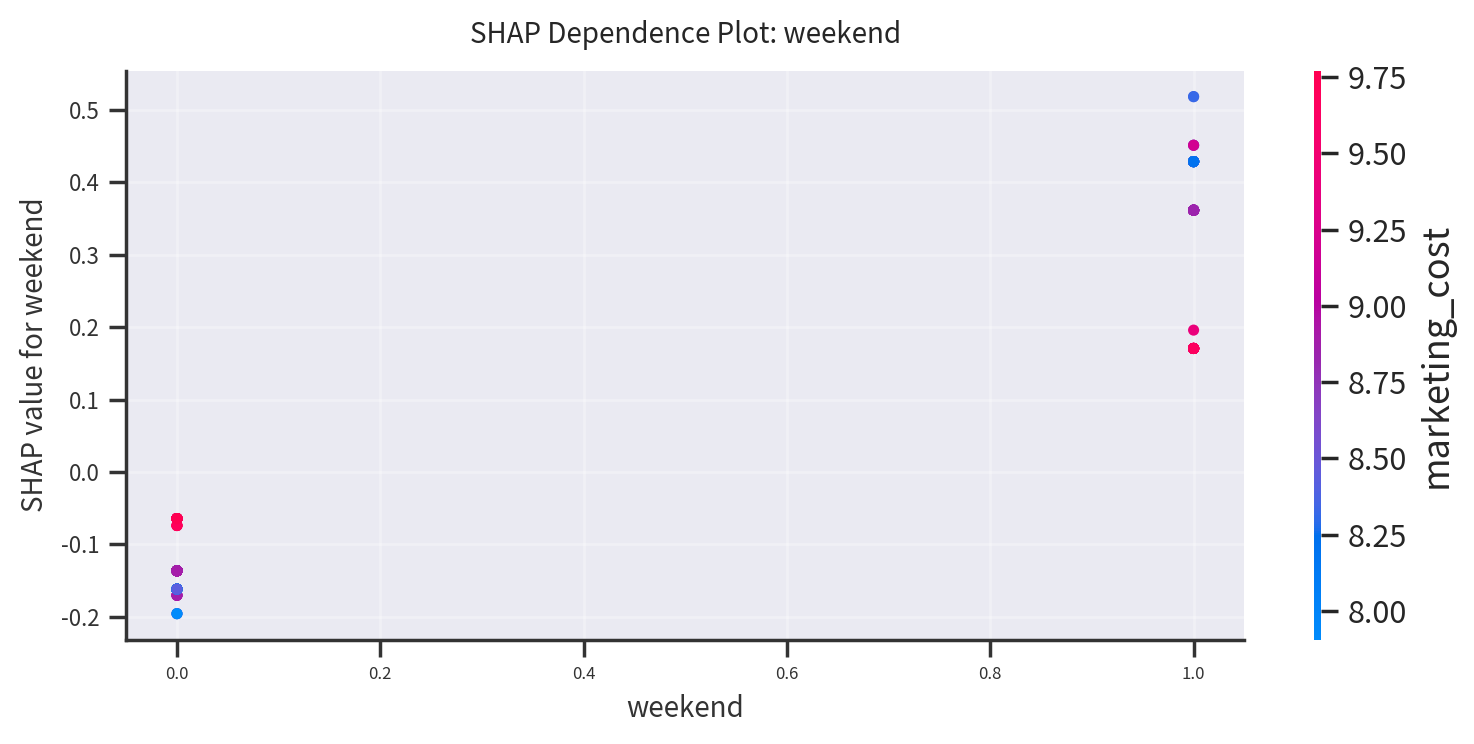

In [13]:
feature_name = "weekend"

shap.dependence_plot(
    feature_name,
    shap_values,
    x_train,
    interaction_index="marketing_cost",
    show=False,
)

fig = plt.gcf()
fig.set_size_inches(1600 / my_dpi, 800 / my_dpi)

plt.title(f"SHAP Dependence Plot: {feature_name}", fontsize=10, pad=10)
plt.xlabel("weekend", fontsize=10)
plt.ylabel("SHAP value for weekend", fontsize=10)
plt.xticks(fontsize=6)
plt.yticks(fontsize=8)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()


#### 💡 인사이트

- ✅ weekend 값에 따른 영향 방향 분리
  - weekend=0 구간의 SHAP 값이 음수(약 -0.20~-0.06) → 매출액 감소 방향 영향
  - weekend=1 구간의 SHAP 값이 양수(약 0.18~0.52) → 매출액 증가 방향 영향

- 🍖 이분형 변수의 명확한 분리
  - 점들이 0과 1에 분포 → 주말 여부가 매출액 영향 방향을 명확히 가르는 변수로 작동

- 🎨 marketing_cost 색상 분포
  - weekend=1 구간에서 색상이 다양하게 분포 → 주말 구간 내에서도 마케팅 비용 수준이 다양하게 존재


### [8] Force Plot (개별 관측치 설명)

- 개별 예측이 왜 그렇게 나왔는지 설명


#### 최대매출

In [14]:
max_index = y_train.idxmax()
pos = x_train.index.get_loc(max_index)
pos


41

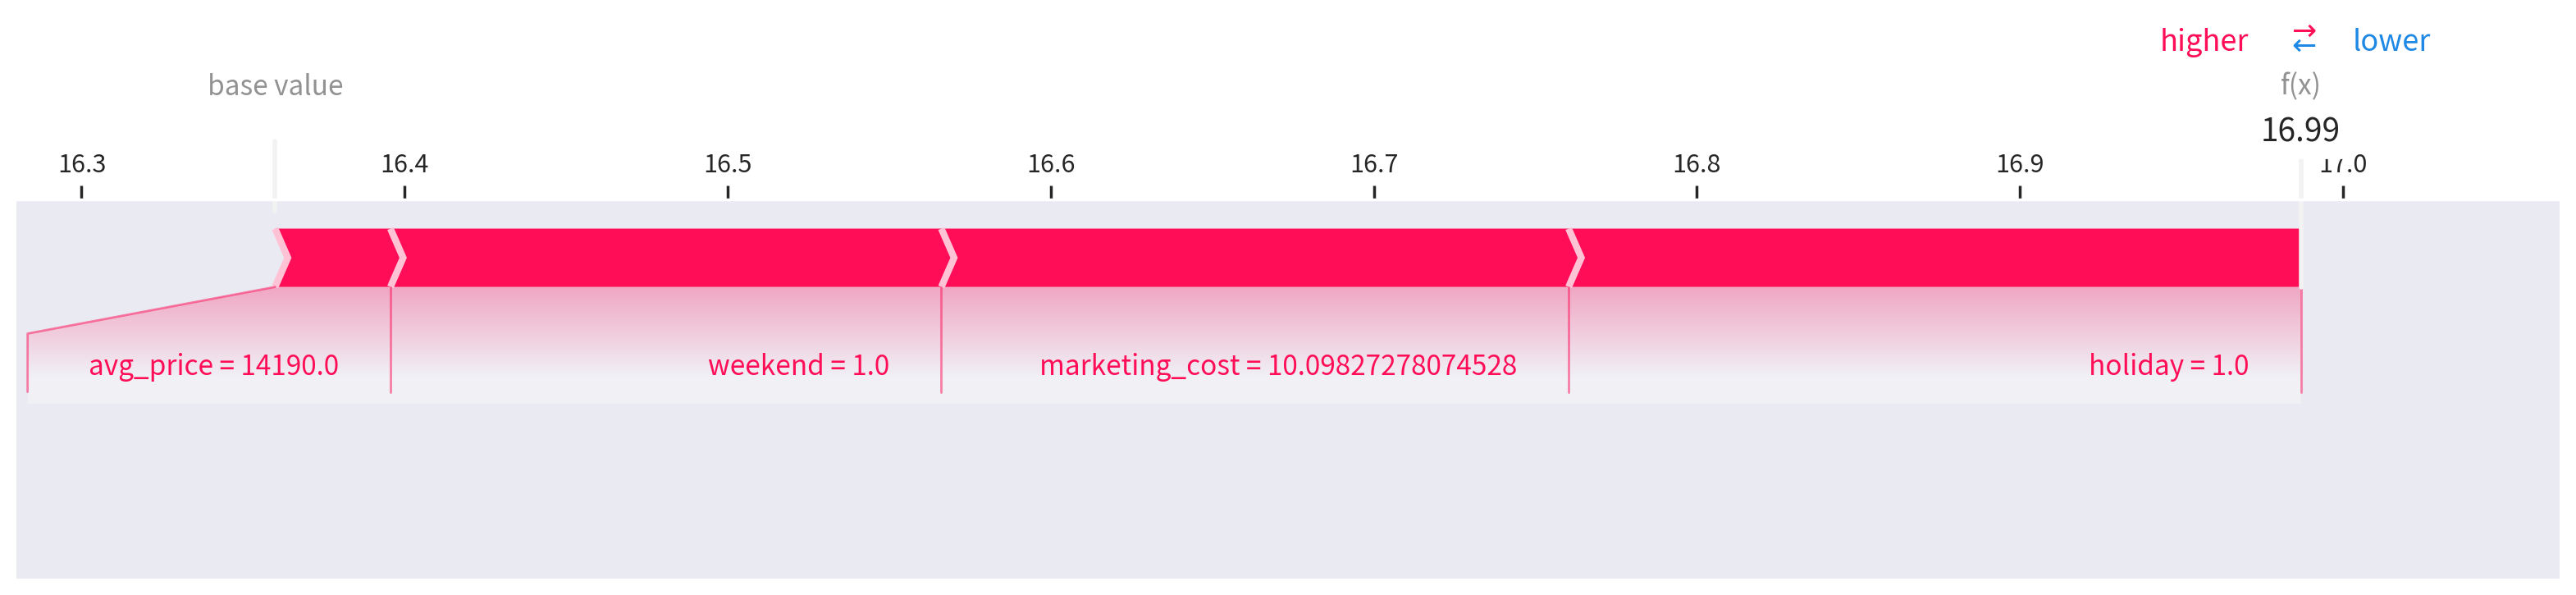

In [15]:
shap.force_plot(
    explainer.expected_value,
    shap_values[pos],
    x_train.iloc[pos],
    matplotlib=True,
)


### 인사이트

- ✅ 예측값이 base value에서 상승
  - f(x)=16.99가 base value(약 16.35~16.4)보다 높음 → 전체적으로 매출 예측이 평균보다 상승함

- ✅ 상승에 기여한 주요 변수
  - avg_price=14190.0, weekend=1.0, marketing_cost=10.098..., holiday=1.0가 모두 빨간색으로 표시 → 예측값을 증가시키는 방향으로 기여함

- 🎯 가장 큰 상승 구간
  - weekend와 marketing_cost 구간의 막대가 길게 표시 → 이 두 변수가 예측 상승에 상대적으로 큰 기여를 함

- 🍀 휴일 효과의 양(+) 기여
  - holiday=1.0이 예측값 상승에 추가적인 기여를 보임


#### 최소매출

In [16]:
min_index = y_train.idxmin()
pos = x_train.index.get_loc(min_index)
pos


230

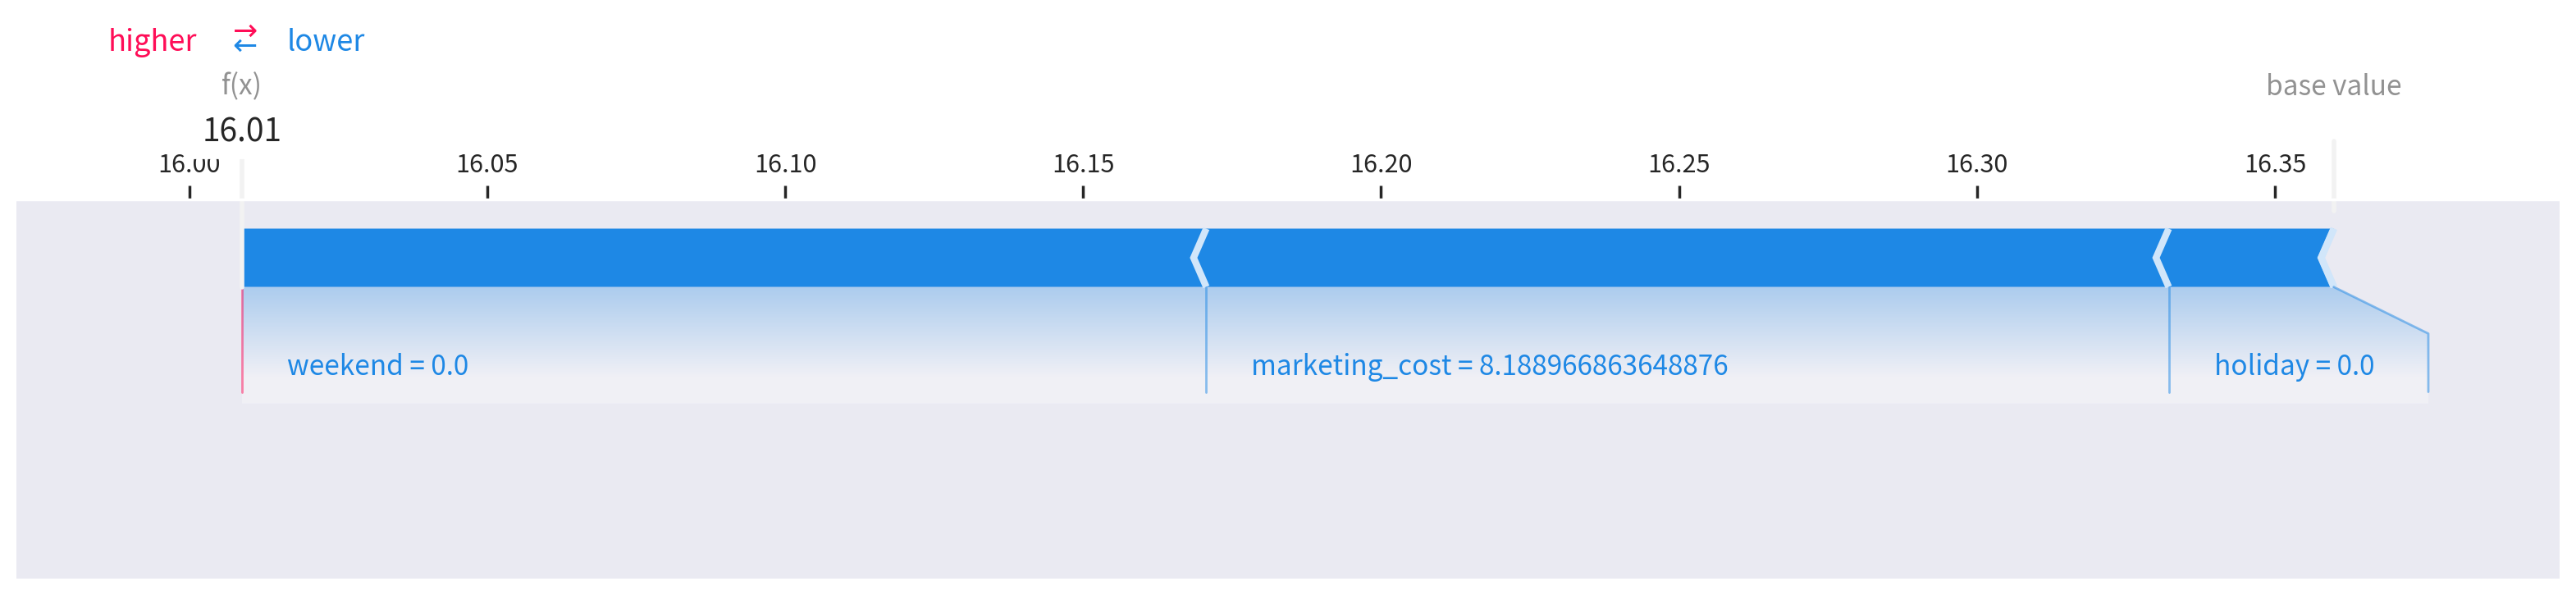

In [17]:
shap.force_plot(
    explainer.expected_value,
    shap_values[pos],
    x_train.iloc[pos],
    matplotlib=True,
)


#### 💡 인사이트 (최소 매출)

- 📉 예측값이 base value보다 낮음
  - f(x)=16.01이 base value(약 16.35)보다 낮음 → 평균 대비 매출 예측이 하락 방향

- 🧊 하락에 기여한 주요 변수
  - weekend=0.0, marketing_cost=8.188..., holiday=0.0가 파란색으로 표시 → 예측값을 낮추는 방향으로 기여함

- 🎯 가장 큰 하락 구간
  - marketing_cost 구간의 파란 막대가 길게 표시 → 예측 하락에 큰 기여를 함

- 🍃 휴일/주말 부재의 영향
  - holiday=0.0과 weekend=0.0이 동시에 하락 방향 기여 → 비휴일·평일 조건이 매출 하락과 연결됨

#### 평균값에 가장 가까운 매출

In [18]:
pos = np.abs(y_train.values - y_train.mean()).argmin()
pos


np.int64(237)

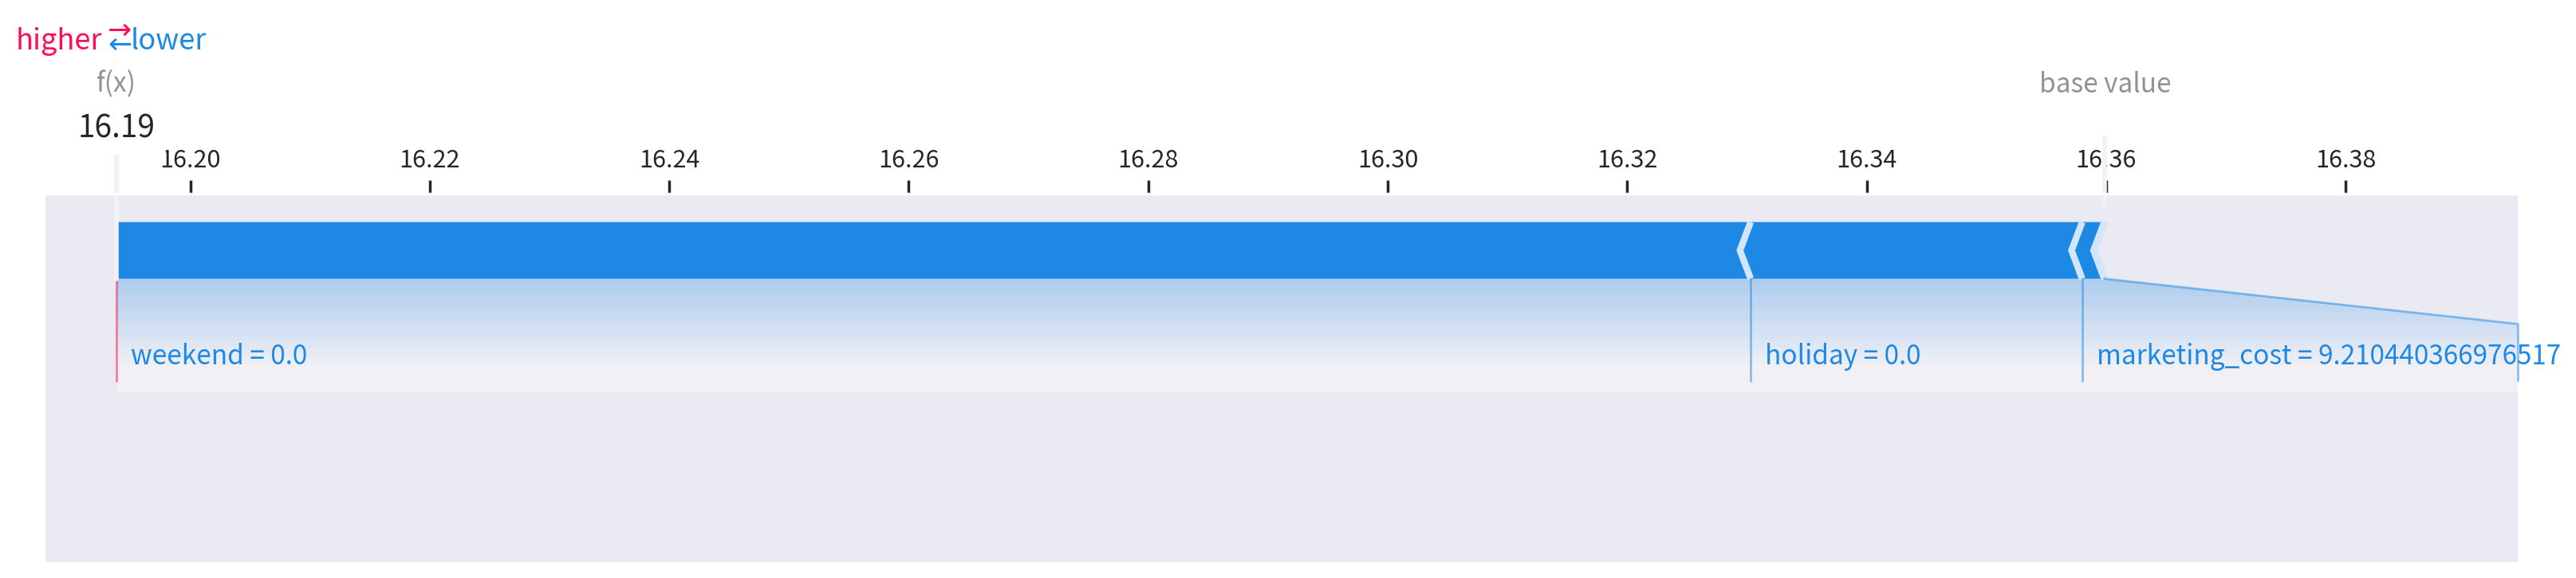

In [19]:
shap.force_plot(
    explainer.expected_value,
    shap_values[pos],
    x_train.iloc[pos],
    matplotlib=True,
)


#### 💡 인사이트 (평균 근접)

- 📉 예측값이 base value보다 낮음
  - f(x)=16.19가 base value(약 16.36)보다 낮음 → 평균 대비 매출 예측이 하락 방향

- 🧊 하락 기여 요인
  - weekend=0.0, holiday=0.0, marketing_cost=9.210...가 모두 파란색 → 예측값을 낮추는 방향 기여

- 🎯 가장 큰 하락 기여
  - weekend 구간의 파란 막대가 길게 표시 → 예측 하락에 가장 큰 영향

- 🍃 비휴일·평일 조건의 동반 효과
  - weekend=0.0과 holiday=0.0이 함께 나타나 하락 방향 강화



#### 중앙값에 가장 가까운 매출

In [20]:
pos = np.abs(y_train.values - y_train.median()).argmin()
pos


np.int64(40)

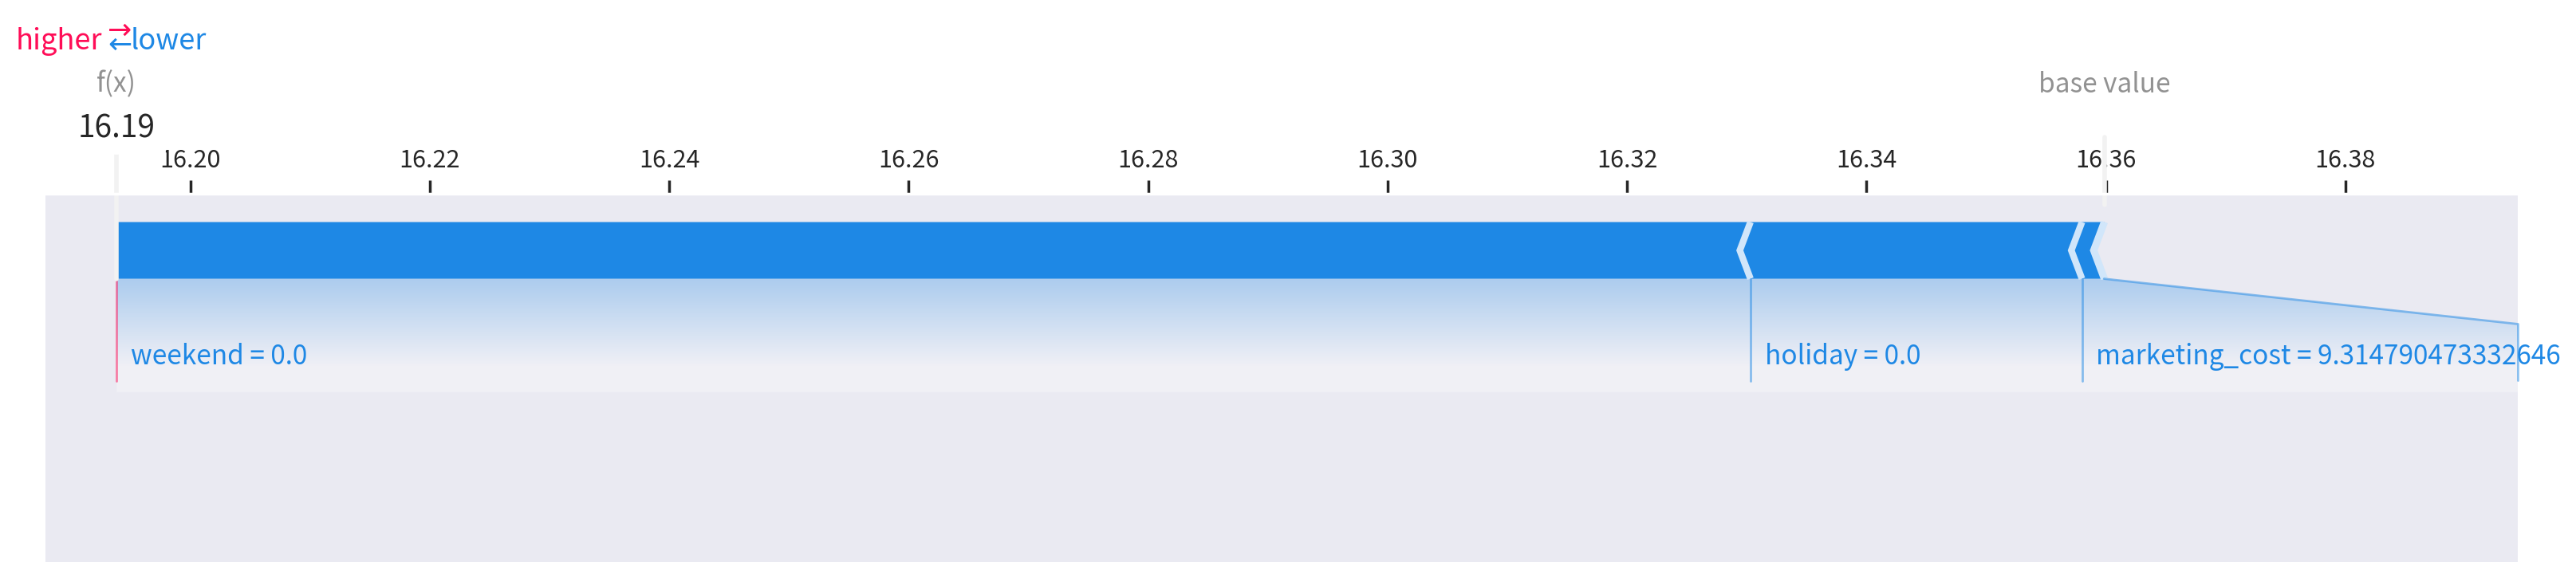

In [21]:
shap.force_plot(
    explainer.expected_value,
    shap_values[pos],
    x_train.iloc[pos],
    matplotlib=True,
)


#### 💡 인사이트 (중앙값 근접)

- 📉 예측값이 base value보다 낮음
  - f(x)=16.19가 base value(약 16.36)보다 낮음 → 평균 대비 매출 예측이 하락 방향

- 🧊 하락 기여 요인
  - weekend=0.0, holiday=0.0, marketing_cost=9.314...가 모두 파란색 → 예측값을 낮추는 방향 기여

- 🎯 가장 큰 하락 기여
  - weekend 구간의 파란 막대가 길게 표시 → 예측 하락에 가장 큰 영향

- 🍃 비휴일·평일 조건의 동반 효과
  - weekend=0.0과 holiday=0.0이 함께 나타나 하락 방향 강화
